<a href="https://colab.research.google.com/github/Usman-938/CCTV-Smart-Change-Detector/blob/main/%E2%9C%85Smart_Object_Detection_Countable_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Smart Object Detection and Automated Counting System
### YOLOv8 + COCO Dataset | Google Colab

**Outputs:** Annotated images · CSV/JSON reports · Performance metrics · Webcam demo

---

## 📦 STEP 1: Install Dependencies

In [1]:
!pip install ultralytics==8.2.0 -q
!pip install opencv-python-headless pandas matplotlib seaborn Pillow roboflow -q
print('✅ All packages installed!')

✅ All packages installed!


## 🔬 STEP 2: Verify GPU & Import Libraries

In [8]:
import torch
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU')

import os, cv2, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from PIL import Image
from pathlib import Path
from datetime import datetime
from collections import defaultdict
warnings.filterwarnings('ignore')

for d in ['outputs/annotated_images','outputs/reports','outputs/metrics','test_images']:
    os.makedirs(d, exist_ok=True)

print('✅ Libraries imported, directories ready!')

CUDA: True
GPU: Tesla T4
✅ Libraries imported, directories ready!


## 🤖 STEP 3: Load YOLOv8 Pretrained Model (COCO 80 classes)

In [11]:
# Model options: yolov8n (fastest) → yolov8s → yolov8m → yolov8l → yolov8x (most accurate)
MODEL_SIZE = 'yolov8s.pt'

# Fix for UnpicklingError with PyTorch 2.6+
import torch
import torch.serialization

# Temporarily patch ultralytics' torch_safe_load to force weights_only=False.
# This is a workaround for specific UnpicklingError with newer PyTorch versions and ultralytics,
# and should only be used if the model source is trusted (e.g., official YOLOv8 models).
def custom_torch_safe_load_patch(weight):
    try:
        # Explicitly try to load with weights_only=False
        ckpt = torch.load(weight, map_location="cpu", weights_only=False)
    except Exception as e:
        # If it still fails, re-raise with a clear message.
        raise type(e)(f"Failed to load weights even with weights_only=False. Original error: {e}\n"+
                      "Consider restarting the runtime or checking ultralytics/PyTorch version compatibility.") from e
    return ckpt, weight

# Apply the patch by replacing the original function in the ultralytics.nn.tasks module.
# This must happen before YOLO is instantiated, so it uses our patched version.
import ultralytics.nn.tasks as ultralytics_tasks
ultralytics_tasks.torch_safe_load = custom_torch_safe_load_patch

# Ensure all necessary ultralytics classes are available and registered as safe globals.
# This is still good practice, even with the patch, for other potential torch.load calls.
from ultralytics.nn.tasks import DetectionModel
from ultralytics.nn.modules import Conv
from torch.nn.modules.container import Sequential

torch.serialization.add_safe_globals([DetectionModel, Conv, Sequential])

# Now, import YOLO and instantiate the model, which will use the patched torch_safe_load.
from ultralytics import YOLO

model = YOLO(MODEL_SIZE)
print(f'✅ Loaded: {MODEL_SIZE}  |  Classes: {len(model.names)}')
print('\n✅ All COCO classes:')
for i, name in model.names.items():
    print(f'  [{i:2d}] {name:<20}', end='' if (i+1)%3 else '\n')

✅ Loaded: yolov8s.pt  |  Classes: 80

✅ All COCO classes:
  [ 0] person                [ 1] bicycle               [ 2] car                 
  [ 3] motorcycle            [ 4] airplane              [ 5] bus                 
  [ 6] train                 [ 7] truck                 [ 8] boat                
  [ 9] traffic light         [10] fire hydrant          [11] stop sign           
  [12] parking meter         [13] bench                 [14] bird                
  [15] cat                   [16] dog                   [17] horse               
  [18] sheep                 [19] cow                   [20] elephant            
  [21] bear                  [22] zebra                 [23] giraffe             
  [24] backpack              [25] umbrella              [26] handbag             
  [27] tie                   [28] suitcase              [29] frisbee             
  [30] skis                  [31] snowboard             [32] sports ball         
  [33] kite                  [34] baseba

## ⚙️ STEP 4: Classroom Configuration & Color Palette

In [12]:
# ── Detection thresholds ────────────────────────────────────
CONF_THRESHOLD = 0.35   # lower → detect more objects (less certain)
IOU_THRESHOLD  = 0.45   # NMS overlap threshold

# ── COCO lookup ─────────────────────────────────────────────
COCO_NAMES  = model.names
NAME_TO_ID  = {v: k for k, v in COCO_NAMES.items()}

# ── Primary classroom focus classes ─────────────────────────
PRIMARY_CLASSES = ['chair','dining table','person','laptop','book','tv','backpack']
PRIMARY_IDS     = [NAME_TO_ID[c] for c in PRIMARY_CLASSES if c in NAME_TO_ID]

# ── Color palette (BGR) ──────────────────────────────────────
CLASS_COLORS = {
    'person':       (0, 220, 0),
    'chair':        (0, 165, 255),
    'dining table': (0, 0, 255),
    'laptop':       (255, 0, 255),
    'book':         (255, 220, 0),
    'tv':           (0, 255, 220),
    'backpack':     (180, 0, 180),
    'clock':        (200, 180, 255),
    'cell phone':   (0, 180, 180),
    'bottle':       (42, 100, 165),
    'default':      (180, 180, 180),
}

print(f'✅ Config ready | Primary classes: {PRIMARY_CLASSES}')
print(f'   conf={CONF_THRESHOLD}  iou={IOU_THRESHOLD}')

✅ Config ready | Primary classes: ['chair', 'dining table', 'person', 'laptop', 'book', 'tv', 'backpack']
   conf=0.35  iou=0.45


## 🔧 STEP 5: Detection Functions

In [13]:
def detect_and_count(image_input, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, save_path=None):
    """
    Run YOLOv8 detection on an image.
    Args:
        image_input : filepath (str) or BGR numpy array
        save_path   : if set, saves annotated image here
    Returns:
        (annotated_bgr, count_dict, detections_list)
    """
    if isinstance(image_input, str):
        img = cv2.imread(image_input)
        if img is None:
            raise ValueError(f'Cannot load image: {image_input}')
    else:
        img = image_input.copy()

    annotated  = img.copy()
    results    = model(img, conf=conf, iou=iou, verbose=False)[0]
    count_dict = defaultdict(int)
    detections = []

    for box in results.boxes:
        cls_id     = int(box.cls[0])
        cls_name   = COCO_NAMES[cls_id]
        confidence = float(box.conf[0])
        x1,y1,x2,y2 = map(int, box.xyxy[0])

        count_dict[cls_name] += 1
        detections.append({'class_id':cls_id,'class_name':cls_name,
                            'confidence':round(confidence,4),
                            'x1':x1,'y1':y1,'x2':x2,'y2':y2})

        color = CLASS_COLORS.get(cls_name, CLASS_COLORS['default'])
        thick = 3 if cls_name in PRIMARY_CLASSES else 2
        cv2.rectangle(annotated,(x1,y1),(x2,y2),color,thick)

        label = f'{cls_name} {confidence:.2f}'
        font  = cv2.FONT_HERSHEY_SIMPLEX
        (lw,lh),base = cv2.getTextSize(label,font,0.5,2)
        cv2.rectangle(annotated,(x1,y1-lh-base-4),(x1+lw,y1),color,-1)
        cv2.putText(annotated,label,(x1,y1-base-2),font,0.5,(0,0,0),2)

    # Count overlay box
    ov = annotated.copy()
    cv2.rectangle(ov,(0,0),(260,28+20*len(count_dict)),(0,0,0),-1)
    cv2.addWeighted(ov,0.55,annotated,0.45,0,annotated)
    cv2.putText(annotated,f'Total: {sum(count_dict.values())}',
                (6,20),cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,255),2)
    for idx,(n,c) in enumerate(sorted(count_dict.items()),1):
        col = CLASS_COLORS.get(n,CLASS_COLORS['default'])
        cv2.putText(annotated,f'  {n}: {c}',(6,20+20*idx),
                    cv2.FONT_HERSHEY_SIMPLEX,0.48,col,1)

    if save_path:
        cv2.imwrite(save_path, annotated)

    return annotated, dict(count_dict), detections


def show_bgr(img, figsize=(13,7), title='Detection'):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=13, fontweight='bold')
    plt.axis('off'); plt.tight_layout(); plt.show()


print('✅ Functions ready!')

✅ Functions ready!


## 🖼️ STEP 6: Download Sample Test Images

In [14]:
import urllib.request

SAMPLES = [
    ('https://ultralytics.com/images/bus.jpg',    'test_images/bus.jpg'),
    ('https://ultralytics.com/images/zidane.jpg', 'test_images/zidane.jpg'),
]

for url, path in SAMPLES:
    try:
        urllib.request.urlretrieve(url, path)
        print(f'✅ Downloaded: {path}')
    except Exception as e:
        print(f'⚠️  {path}: {e}')

print('\n💡 TIP: Upload your own classroom photos via Files panel (left sidebar).')
print('        Drag images into the  test_images/  folder.')

✅ Downloaded: test_images/bus.jpg
✅ Downloaded: test_images/zidane.jpg

💡 TIP: Upload your own classroom photos via Files panel (left sidebar).
        Drag images into the  test_images/  folder.


## 🔍 STEP 7: Run Object Detection on All Images


🔍 bus.jpg
   ⏱ 6917.0 ms  |  Objects: 5
      • bus: 1
      • person: 4


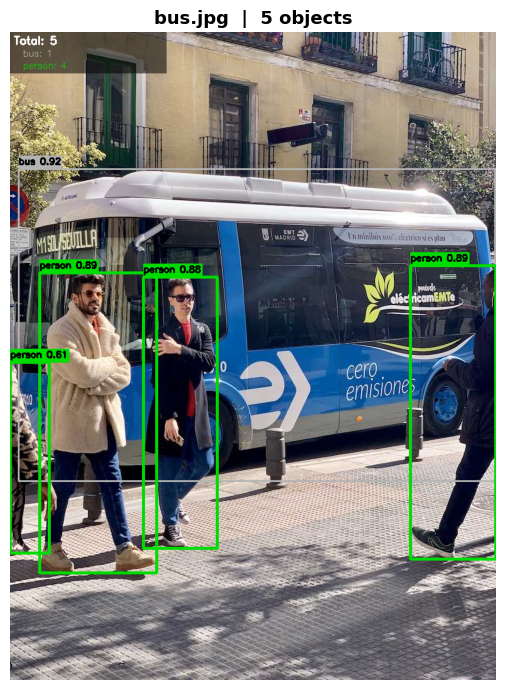


🔍 zidane.jpg
   ⏱ 86.6 ms  |  Objects: 3
      • person: 2
      • tie: 1


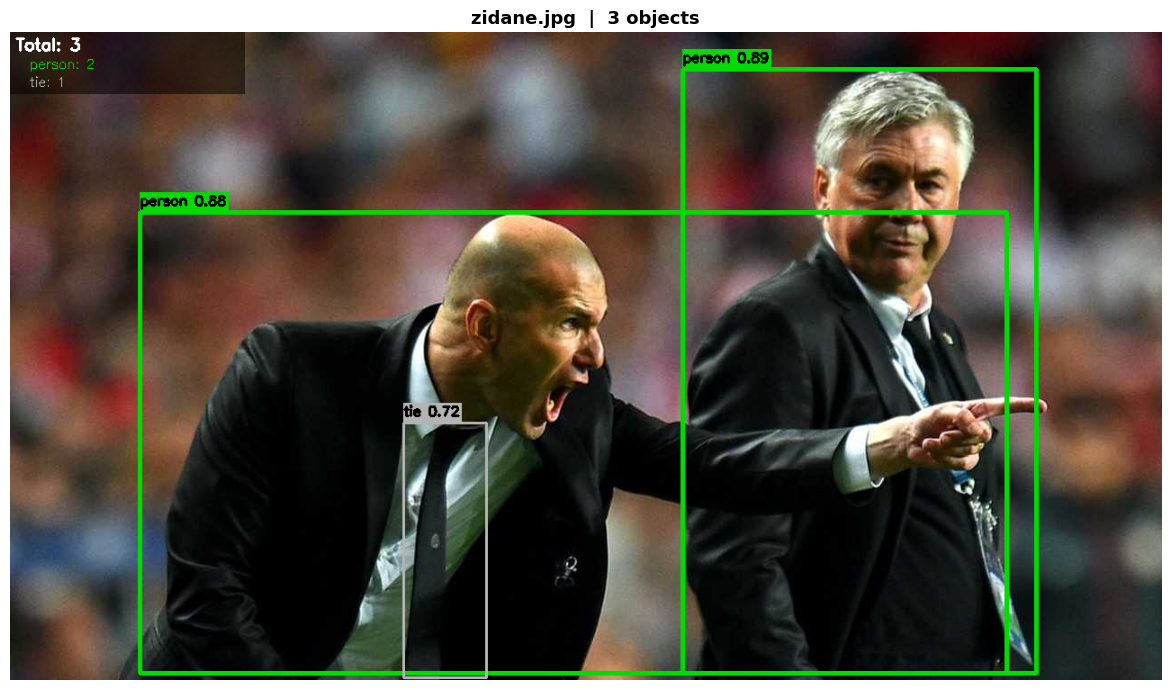


✅ Detection complete!


In [15]:
# ── Upload your own image (optional) ────────────────────────
# from google.colab import files
# uploaded = files.upload()    # click to upload
# for fname in uploaded:
#     import shutil
#     shutil.move(fname, f'test_images/{fname}')

all_results = []
image_paths = list(Path('test_images').glob('*.jpg')) + \
              list(Path('test_images').glob('*.png')) + \
              list(Path('test_images').glob('*.jpeg'))

if not image_paths:
    print('⚠️  No images in test_images/. Run Step 6 or upload your own.')
else:
    for img_path in sorted(image_paths):
        print(f'\n🔍 {img_path.name}')
        t0 = time.time()
        save_out = f'outputs/annotated_images/annotated_{img_path.stem}.jpg'
        annotated, counts, dets = detect_and_count(str(img_path), save_path=save_out)
        ms = (time.time()-t0)*1000
        print(f'   ⏱ {ms:.1f} ms  |  Objects: {sum(counts.values())}')
        for cls,cnt in sorted(counts.items()):
            print(f'      • {cls}: {cnt}')
        all_results.append({'image':img_path.name,'inference_ms':round(ms,2),
                             'total_objects':sum(counts.values()),**counts})
        show_bgr(annotated, title=f'{img_path.name}  |  {sum(counts.values())} objects')
print('\n✅ Detection complete!')

## 📋 STEP 8: Export CSV & JSON Count Reports

In [16]:
if not all_results:
    print('⚠️  Run Step 7 first.')
else:
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')

    # CSV
    df = pd.DataFrame(all_results).fillna(0)
    cnt_cols = [c for c in df.columns if c not in ['image','inference_ms']]
    df[cnt_cols] = df[cnt_cols].astype(int)
    csv_path = f'outputs/reports/detection_report_{ts}.csv'
    df.to_csv(csv_path, index=False)
    print(f'✅ CSV saved: {csv_path}')
    display(df)

    # JSON
    report = {
        'generated_at': datetime.now().isoformat(),
        'model': MODEL_SIZE,
        'conf_threshold': CONF_THRESHOLD,
        'iou_threshold':  IOU_THRESHOLD,
        'summary': {
            'total_images':   len(all_results),
            'total_objects':  sum(r['total_objects'] for r in all_results),
            'avg_inf_ms':     round(sum(r['inference_ms'] for r in all_results)/len(all_results),2)
        },
        'per_image': all_results
    }
    json_path = f'outputs/reports/detection_report_{ts}.json'
    with open(json_path,'w') as f:
        json.dump(report, f, indent=2)
    print(f'✅ JSON saved: {json_path}')
    print(json.dumps(report['summary'], indent=2))

✅ CSV saved: outputs/reports/detection_report_20260303_170152.csv


,image,inference_ms,total_objects,bus,person,tie
0,bus.jpg,6917.02,5,1,4,0
1,zidane.jpg,86.62,3,0,2,1


✅ JSON saved: outputs/reports/detection_report_20260303_170152.json
{
  "total_images": 2,
  "total_objects": 8,
  "avg_inf_ms": 3501.82
}


## 📊 STEP 9: Performance Metrics & Visualizations

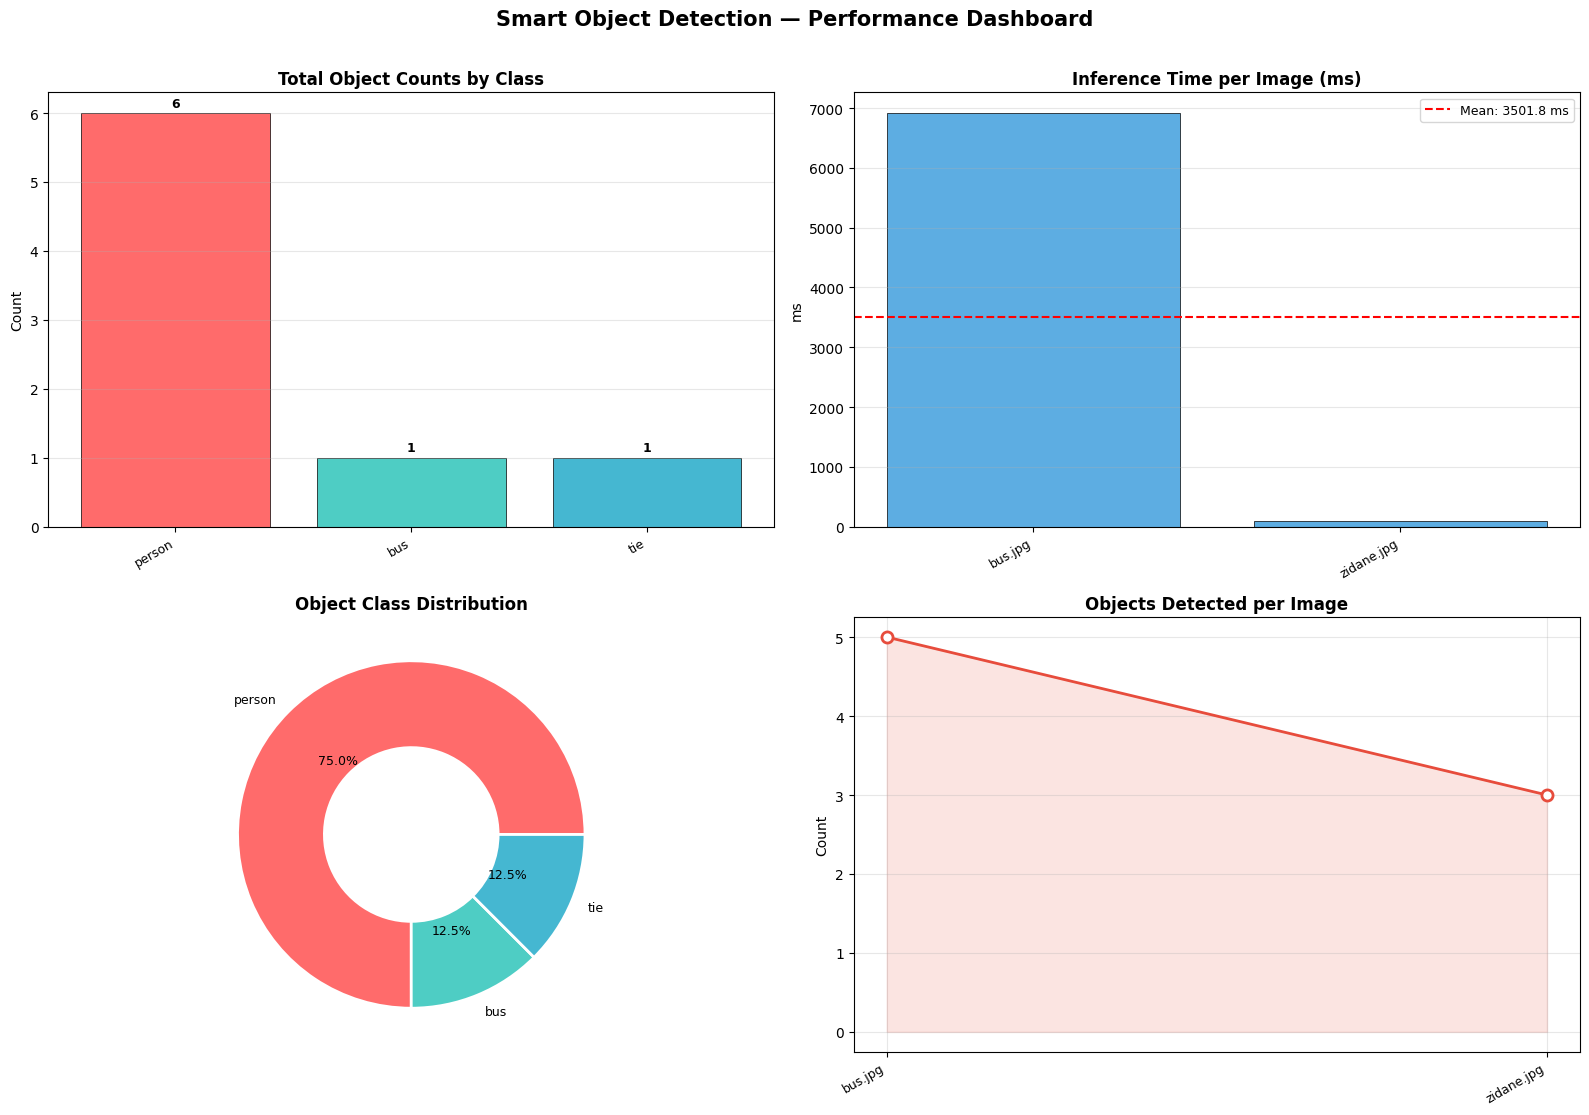

✅ Dashboard saved: outputs/metrics/dashboard_20260303_170208.png

📊 Summary:
  Images processed : 2
  Total detections : 8
  Avg objects/img  : 4.00
  Avg inference    : 3501.8 ms
  Min / Max inf    : 86.6 / 6917.0 ms


In [17]:
if not all_results:
    print('⚠️  Run Steps 7-8 first.')
else:
    df = pd.DataFrame(all_results).fillna(0)
    meta = ['image','inference_ms','total_objects']
    obj_cols = [c for c in df.columns if c not in meta]
    total_counts = df[obj_cols].sum().sort_values(ascending=False)
    total_counts = total_counts[total_counts > 0]

    COLORS = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7',
              '#DDA0DD','#98D8C8','#F7DC6F','#82E0AA','#AED6F1']

    fig, axes = plt.subplots(2,2,figsize=(16,11))
    fig.suptitle('Smart Object Detection — Performance Dashboard',
                 fontsize=15, fontweight='bold', y=1.01)

    # Plot 1: Object counts bar
    ax1 = axes[0,0]
    bars = ax1.bar(range(len(total_counts)), total_counts.values,
                   color=COLORS[:len(total_counts)], edgecolor='black', lw=0.5)
    ax1.set_xticks(range(len(total_counts)))
    ax1.set_xticklabels(total_counts.index, rotation=30, ha='right', fontsize=9)
    ax1.set_title('Total Object Counts by Class', fontweight='bold')
    ax1.set_ylabel('Count')
    for bar,val in zip(bars,total_counts.values):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 str(int(val)), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    # Plot 2: Inference time
    ax2 = axes[0,1]
    ax2.bar(range(len(df)), df['inference_ms'],
            color='#5DADE2', edgecolor='black', lw=0.5)
    ax2.axhline(df['inference_ms'].mean(), color='red', ls='--',
                label=f'Mean: {df["inference_ms"].mean():.1f} ms')
    ax2.set_xticks(range(len(df)))
    ax2.set_xticklabels(df['image'].str[:14], rotation=30, ha='right', fontsize=9)
    ax2.set_title('Inference Time per Image (ms)', fontweight='bold')
    ax2.set_ylabel('ms'); ax2.legend(fontsize=9); ax2.grid(axis='y',alpha=0.3)

    # Plot 3: Pie chart
    ax3 = axes[1,0]
    wedge = dict(width=0.5, edgecolor='white', linewidth=2)
    ax3.pie(total_counts.values, labels=total_counts.index,
            autopct='%1.1f%%', colors=COLORS[:len(total_counts)],
            wedgeprops=wedge, textprops={'fontsize':9})
    ax3.set_title('Object Class Distribution', fontweight='bold')

    # Plot 4: Objects per image trend
    ax4 = axes[1,1]
    ax4.plot(range(len(df)), df['total_objects'], 'o-',
             color='#E74C3C', lw=2, ms=8, mfc='white', mew=2)
    ax4.fill_between(range(len(df)), df['total_objects'], alpha=0.15, color='#E74C3C')
    ax4.set_xticks(range(len(df)))
    ax4.set_xticklabels(df['image'].str[:14], rotation=30, ha='right', fontsize=9)
    ax4.set_title('Objects Detected per Image', fontweight='bold')
    ax4.set_ylabel('Count'); ax4.grid(alpha=0.3)

    plt.tight_layout()
    dash_path = f'outputs/metrics/dashboard_{datetime.now().strftime("%Y%m%d_%H%M%S")}.png'
    plt.savefig(dash_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Dashboard saved: {dash_path}')

    print('\n📊 Summary:')
    print(f'  Images processed : {len(df)}')
    print(f'  Total detections : {int(df["total_objects"].sum())}')
    print(f'  Avg objects/img  : {df["total_objects"].mean():.2f}')
    print(f'  Avg inference    : {df["inference_ms"].mean():.1f} ms')
    print(f'  Min / Max inf    : {df["inference_ms"].min():.1f} / {df["inference_ms"].max():.1f} ms')

## 🎥 STEP 10: Real-Time Webcam Detection

📷 Starting webcam capture (5 frames)...
   Your browser will ask for camera permission — please ALLOW.
✅ Captured 5 frames!


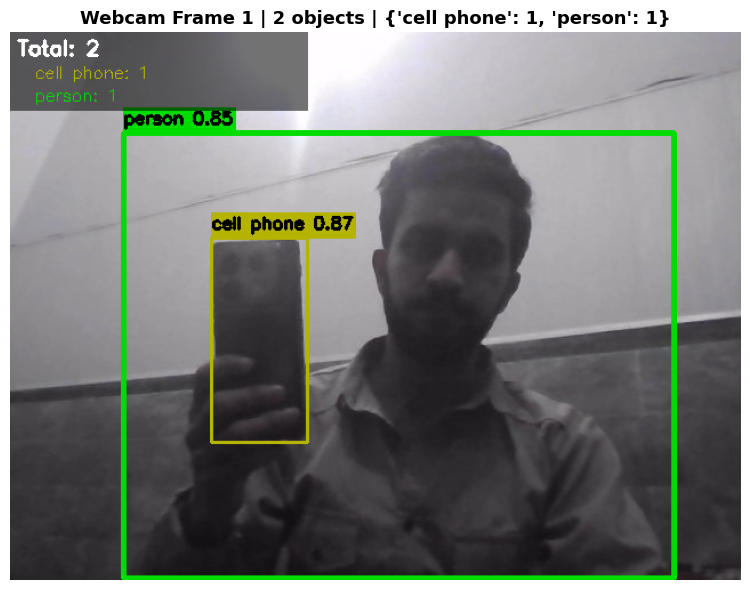

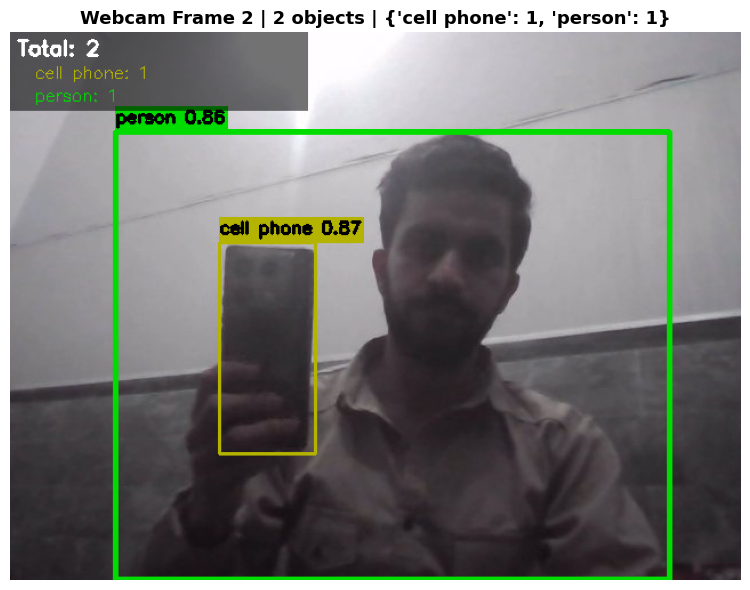

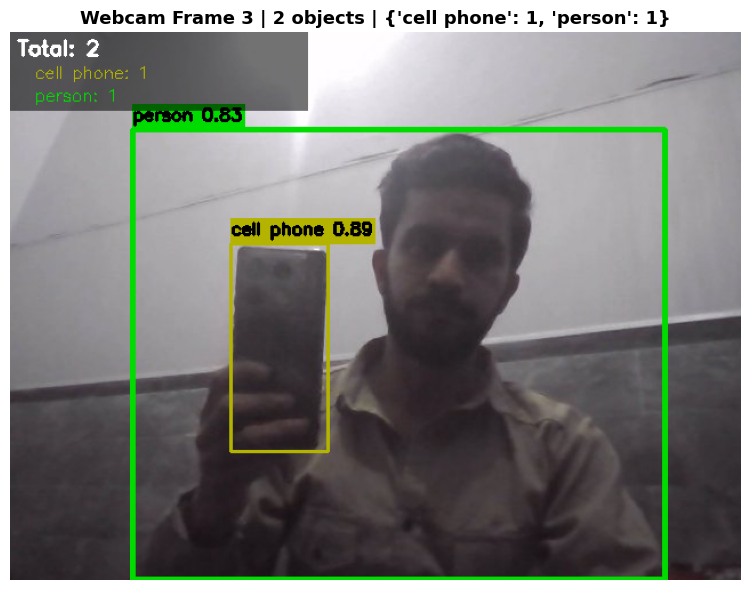

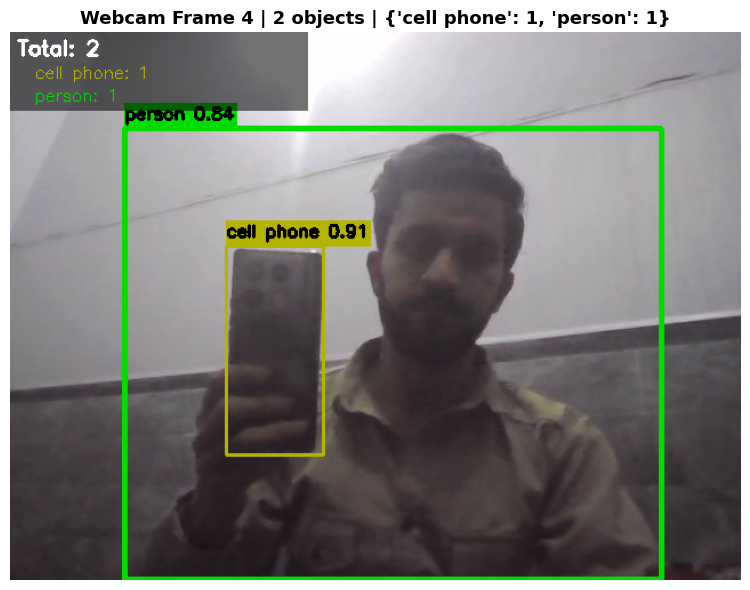

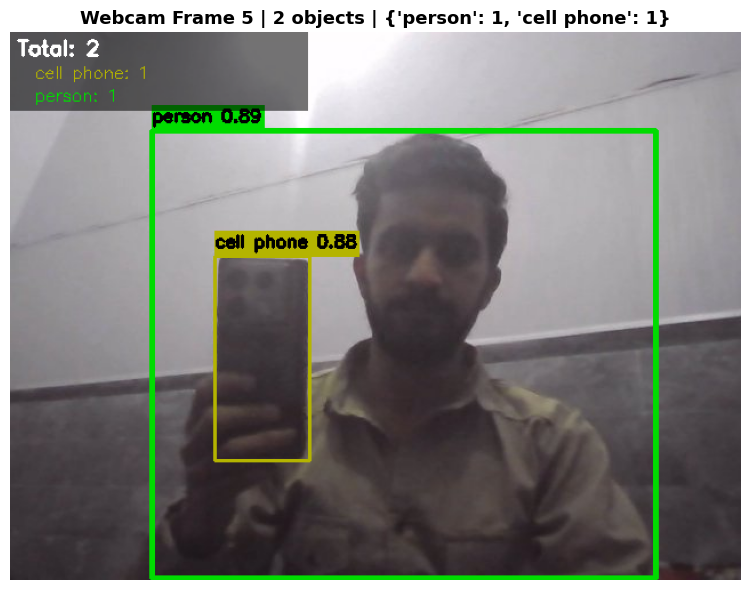

✅ Webcam detection complete!


In [29]:
from IPython.display import Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode

def js_to_bgr(js_reply):
    data = b64decode(js_reply.split(',')[1])
    arr  = np.frombuffer(data, dtype=np.uint8)
    return cv2.imdecode(arr, flags=1)

WEBCAM_JS = """
async function captureFrames(n, delay) {
  const vid = document.createElement('video');
  const stream = await navigator.mediaDevices.getUserMedia({video: true});
  vid.srcObject = stream;
  await vid.play();
  const canvas = document.createElement('canvas');
  canvas.width = 640; canvas.height = 480;
  const ctx = canvas.getContext('2d');
  const frames = [];
  for (let i = 0; i < n; i++) {
    await new Promise(r => setTimeout(r, delay));
    ctx.drawImage(vid, 0, 0, 640, 480);
    frames.push(canvas.toDataURL('image/jpeg', 0.85));
  }
  stream.getTracks().forEach(t => t.stop());
  return frames;
}
captureFrames(5, 600)
"""

print('📷 Starting webcam capture (5 frames)...')
print('   Your browser will ask for camera permission — please ALLOW.')
try:
    frames = eval_js(WEBCAM_JS)
    print(f'✅ Captured {len(frames)} frames!')
    for i, frame_b64 in enumerate(frames):
        frame_bgr = js_to_bgr(frame_b64)
        save_p    = f'outputs/annotated_images/webcam_frame_{i+1:02d}.jpg'
        annotated, counts, _ = detect_and_count(frame_bgr, save_path=save_p)
        show_bgr(annotated, figsize=(10,6),
                 title=f'Webcam Frame {i+1} | {sum(counts.values())} objects | {counts}')
    print('✅ Webcam detection complete!')
except Exception as e:
    print(f'⚠️  Webcam unavailable: {e}')
    print('   → Upload classroom images to test_images/ and use Step 7 instead.')

## 🎬 STEP 11 (Optional): Video File Detection

In [36]:
# ── Upload a video ─────────────────────────────────
# from google.colab import files
# uploaded = files.upload()
# VIDEO_PATH = list(uploaded.keys())[0]

VIDEO_PATH = '/content/WhatsApp Video 2026-02-24 at 12.41.23 AM.mp4'  # Set path above

def process_video(vpath, out_path='outputs/annotated_video.mp4', skip=2):
    cap = cv2.VideoCapture(vpath)
    if not cap.isOpened():
        print(f'❌ Cannot open: {vpath}'); return
    fps   = cap.get(cv2.CAP_PROP_FPS)
    w     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'▶️ {vpath}  |  {w}x{h}  {fps:.0f}fps  {total} frames')
    out   = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w,h))
    cumulative = defaultdict(int)
    fidx = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if fidx % skip == 0:
            annotated, counts, _ = detect_and_count(frame)
            for k,v in counts.items(): cumulative[k] += v
            out.write(annotated)
        else:
            out.write(frame)
        if fidx % 60 == 0: print(f'  frame {fidx}/{total}...')
        fidx += 1
    cap.release(); out.release()
    print(f'✅ Saved: {out_path}')
    print(f'   Cumulative counts: {dict(cumulative)}')

if VIDEO_PATH and os.path.exists(VIDEO_PATH):
    process_video(VIDEO_PATH)
else:
    print('ℹ️  No video set. Uncomment the upload block above to use this step.')

▶️ /content/WhatsApp Video 2026-02-24 at 12.41.23 AM.mp4  |  478x850  30fps  1250 frames
  frame 0/1250...
  frame 60/1250...
  frame 120/1250...
  frame 180/1250...
  frame 240/1250...
  frame 300/1250...
  frame 360/1250...
  frame 420/1250...
  frame 480/1250...
  frame 540/1250...
  frame 600/1250...
  frame 660/1250...
  frame 720/1250...
  frame 780/1250...
  frame 840/1250...
  frame 900/1250...
  frame 960/1250...
  frame 1020/1250...
  frame 1080/1250...
  frame 1140/1250...
  frame 1200/1250...
✅ Saved: outputs/annotated_video.mp4
   Cumulative counts: {'book': 204, 'sports ball': 54, 'person': 70, 'car': 1, 'baseball glove': 1, 'skateboard': 2, 'mouse': 2, 'bottle': 1}


## 🏋️ STEP 12 (Optional): Fine-Tune on Custom Classroom Dataset

In [37]:
# ─────────────────────────────────────────────────────────────────────────
# Fine-tuning lets you add classes COCO doesn't have:
#   ceiling_fan, whiteboard, projector, door, window ...
#
# HOW TO GET A CUSTOM DATASET:
#   1. Visit https://roboflow.com
#   2. Search 'classroom objects' or upload your own images
#   3. Annotate with bounding boxes
#   4. Export → YOLOv8 format → copy API snippet below
# ─────────────────────────────────────────────────────────────────────────

# ── Option A: Roboflow API ─────────────────────────────────────────────────
# from roboflow import Roboflow
# rf      = Roboflow(api_key='YOUR_ROBOFLOW_API_KEY')
# project = rf.workspace('YOUR_WS').project('YOUR_PROJECT')
# dataset = project.version(1).download('yolov8')
# DATA_YAML = dataset.location + '/data.yaml'

# ── Option B: Manual data.yaml ─────────────────────────────────────────────
DATA_YAML_CONTENT = """path: /content/classroom_dataset
train: images/train
val:   images/val
test:  images/test
nc: 6
names: ['chair', 'table', 'fan', 'board', 'person', 'laptop']
"""
os.makedirs('classroom_dataset', exist_ok=True)
with open('classroom_dataset/data.yaml','w') as f:
    f.write(DATA_YAML_CONTENT)
print('📄 classroom_dataset/data.yaml created!')

# ── Training command (run when your dataset is ready) ──────────────────────
TRAIN_CMD = """
model_ft = YOLO('yolov8s.pt')   # Start from COCO pretrained weights
results  = model_ft.train(
    data     = 'classroom_dataset/data.yaml',
    epochs   = 50,
    imgsz    = 640,
    batch    = 16,
    name     = 'classroom_v1',
    patience = 10,
    device   = 0 if torch.cuda.is_available() else 'cpu'
)
# Evaluate after training:
metrics = model_ft.val()
print(f'mAP50     : {metrics.box.map50:.4f}')
print(f'mAP50-95  : {metrics.box.map:.4f}')
print(f'Precision : {metrics.box.mp:.4f}')
print(f'Recall    : {metrics.box.mr:.4f}')
"""
print('Training code (run after adding images to classroom_dataset/):')
print(TRAIN_CMD)

📄 classroom_dataset/data.yaml created!
Training code (run after adding images to classroom_dataset/):

model_ft = YOLO('yolov8s.pt')   # Start from COCO pretrained weights
results  = model_ft.train(
    data     = 'classroom_dataset/data.yaml',
    epochs   = 50,
    imgsz    = 640,
    batch    = 16,
    name     = 'classroom_v1',
    patience = 10,
    device   = 0 if torch.cuda.is_available() else 'cpu'
)
# Evaluate after training:
metrics = model_ft.val()
print(f'mAP50     : {metrics.box.map50:.4f}')
print(f'mAP50-95  : {metrics.box.map:.4f}')
print(f'Precision : {metrics.box.mp:.4f}')
print(f'Recall    : {metrics.box.mr:.4f}')



## 📤 STEP 13: Download All Outputs

In [38]:
import shutil
from google.colab import files

print('📁 Output files:')
for root, dirs, fnames in os.walk('outputs'):
    for fn in fnames:
        fp   = os.path.join(root, fn)
        size = os.path.getsize(fp)
        print(f'  {fp}  ({size/1024:.1f} KB)')

zip_name = f'detection_outputs_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
shutil.make_archive(zip_name, 'zip', 'outputs')
print(f'\n✅ Zipped: {zip_name}.zip')
files.download(f'{zip_name}.zip')

📁 Output files:
  outputs/annotated_video.mp4  (16233.1 KB)
  outputs/reports/detection_report_20260303_170152.json  (0.5 KB)
  outputs/reports/detection_report_20260303_170152.csv  (0.1 KB)
  outputs/annotated_images/annotated_bus.jpg  (349.1 KB)
  outputs/annotated_images/webcam_frame_05.jpg  (52.2 KB)
  outputs/annotated_images/webcam_frame_04.jpg  (53.0 KB)
  outputs/annotated_images/annotated_zidane.jpg  (151.9 KB)
  outputs/annotated_images/webcam_frame_02.jpg  (54.4 KB)
  outputs/annotated_images/webcam_frame_03.jpg  (52.4 KB)
  outputs/annotated_images/webcam_frame_01.jpg  (54.0 KB)
  outputs/metrics/dashboard_20260303_170208.png  (144.9 KB)

✅ Zipped: detection_outputs_20260303_171915.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## ✅ Project Complete!

| Component | Status |
|---|---|
| YOLOv8s pretrained (COCO 80 classes) | ✅ |
| Object detection on images | ✅ |
| Annotated image output (bounding boxes) | ✅ |
| CSV + JSON count reports | ✅ |
| 4-panel performance dashboard | ✅ |
| Real-time webcam detection | ✅ |
| Video file processing | ✅ |
| Custom fine-tuning guide | ✅ |
